# Phân tích các yếu tố ảnh hưởng đến số năm đi học (`educ`)

**Dataset:** `wage.xlsx` (Card, 1995 - National Longitudinal Survey of Young Men)

**Mục tiêu:** Xác định các yếu tố (gia đình, năng lực nhận thức, địa lý) ảnh hưởng đến số năm đi học (`educ`).

**Nội dung notebook:**
1. Load dữ liệu & tổng quan
2. EDA đầy đủ (bảng + trực quan hóa với matplotlib/seaborn)
3. OLS: 3 mô hình theo nhóm biến (statsmodels)
4. ML: Linear Regression, Ridge, Lasso, Random Forest Regressor
5. Đánh giá: RMSE, MAE, R²
6. So sánh bằng Cross-Validation
7. Feature Importance


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import statsmodels.api as sm

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)


## 1. Load dữ liệu & tổng quan

In [11]:
df = pd.read_csv("data/wage.csv")
print("Shape:", df.shape)
df.head()


Shape: (3010, 34)


,id,nearc2,nearc4,educ,age,fatheduc,motheduc,weight,momdad14,sinmom14,step14,reg661,reg662,reg663,reg664,reg665,reg666,reg667,reg668,reg669,south66,black,smsa,south,smsa66,wage,enroll,KWW,IQ,married,libcrd14,exper,lwage,expersq
0,2,0,0,7,29,NaN,NaN,158413,1,0,0,1,0,0,0,0,0,0,0,0,0,1,1,0,1,548,0,15.0,NaN,1.0,0.0,16,"6,306274891",256
1,3,0,0,12,27,8.0,8.0,380166,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,481,0,35.0,93.0,1.0,1.0,9,"6,175867081",81
2,4,0,0,12,34,14.0,12.0,367470,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,721,0,42.0,103.0,1.0,1.0,16,"6,580638885",256
3,5,1,1,11,27,11.0,12.0,380166,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,250,0,25.0,88.0,1.0,1.0,10,"5,52146101",100
4,6,1,1,12,34,8.0,7.0,367470,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,729,0,34.0,108.0,1.0,0.0,16,"6,591673851",256


In [12]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3010 entries, 0 to 3009
Data columns (total 34 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        3010 non-null   int64  
 1   nearc2    3010 non-null   int64  
 2   nearc4    3010 non-null   int64  
 3   educ      3010 non-null   int64  
 4   age       3010 non-null   int64  
 5   fatheduc  2320 non-null   float64
 6   motheduc  2657 non-null   float64
 7   weight    3010 non-null   int64  
 8   momdad14  3010 non-null   int64  
 9   sinmom14  3010 non-null   int64  
 10  step14    3010 non-null   int64  
 11  reg661    3010 non-null   int64  
 12  reg662    3010 non-null   int64  
 13  reg663    3010 non-null   int64  
 14  reg664    3010 non-null   int64  
 15  reg665    3010 non-null   int64  
 16  reg666    3010 non-null   int64  
 17  reg667    3010 non-null   int64  
 18  reg668    3010 non-null   int64  
 19  reg669    3010 non-null   int64  
 20  south66   3010 non-null   int64  
 21  bl

## 2. EDA đầy đủ

### 2.1 Bảng: Missing values & kiểu dữ liệu

In [13]:
info = pd.DataFrame({
    "dtype": df.dtypes,
    "n_missing": df.isnull().sum(),
    "pct_missing": (df.isnull().sum() / len(df) * 100).round(2),
    "n_unique": df.nunique()
})
info.sort_values("pct_missing", ascending=False)


,dtype,n_missing,pct_missing,n_unique
IQ,float64,949,31.53,92
fatheduc,float64,690,22.92,19
motheduc,float64,353,11.73,19
KWW,float64,47,1.56,50
libcrd14,float64,13,0.43,2
married,float64,7,0.23,6
nearc2,int64,0,0.00,2
id,int64,0,0.00,3010
educ,int64,0,0.00,18
nearc4,int64,0,0.00,2


### 2.2 Bảng: Thống kê mô tả các biến định lượng chính

In [14]:
num_vars = ["educ", "age", "fatheduc", "motheduc", "IQ", "KWW", "exper", "wage", "lwage"]
desc = df[num_vars].describe().T
desc.round(2)


,count,mean,std,min,25%,50%,75%,max
educ,3010.0,13.26,2.68,1.0,12.00,13.0,16.00,18.0
age,3010.0,28.12,3.14,24.0,25.00,28.0,31.00,34.0
fatheduc,2320.0,10.00,3.72,0.0,8.00,10.0,12.00,18.0
motheduc,2657.0,10.35,3.18,0.0,8.00,12.0,12.00,18.0
IQ,2061.0,102.45,15.42,50.0,93.00,103.0,113.00,149.0
KWW,2963.0,33.54,8.61,4.0,28.00,34.0,40.00,56.0
exper,3010.0,8.86,4.14,0.0,6.00,8.0,11.00,23.0
wage,3010.0,577.28,262.96,100.0,394.25,537.5,708.75,2404.0


### 2.3 Trực quan hóa: Phân phối `educ`

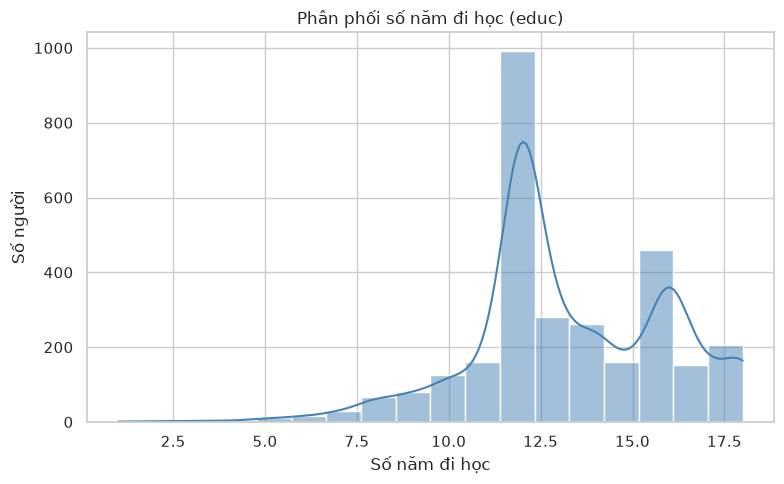

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df["educ"], bins=18, kde=True, color="steelblue", ax=ax)
ax.set_title("Phân phối số năm đi học (educ)")
ax.set_xlabel("Số năm đi học")
ax.set_ylabel("Số người")
plt.tight_layout()
plt.show()


### 2.4 Trực quan hóa: Phân phối các biến định lượng chính

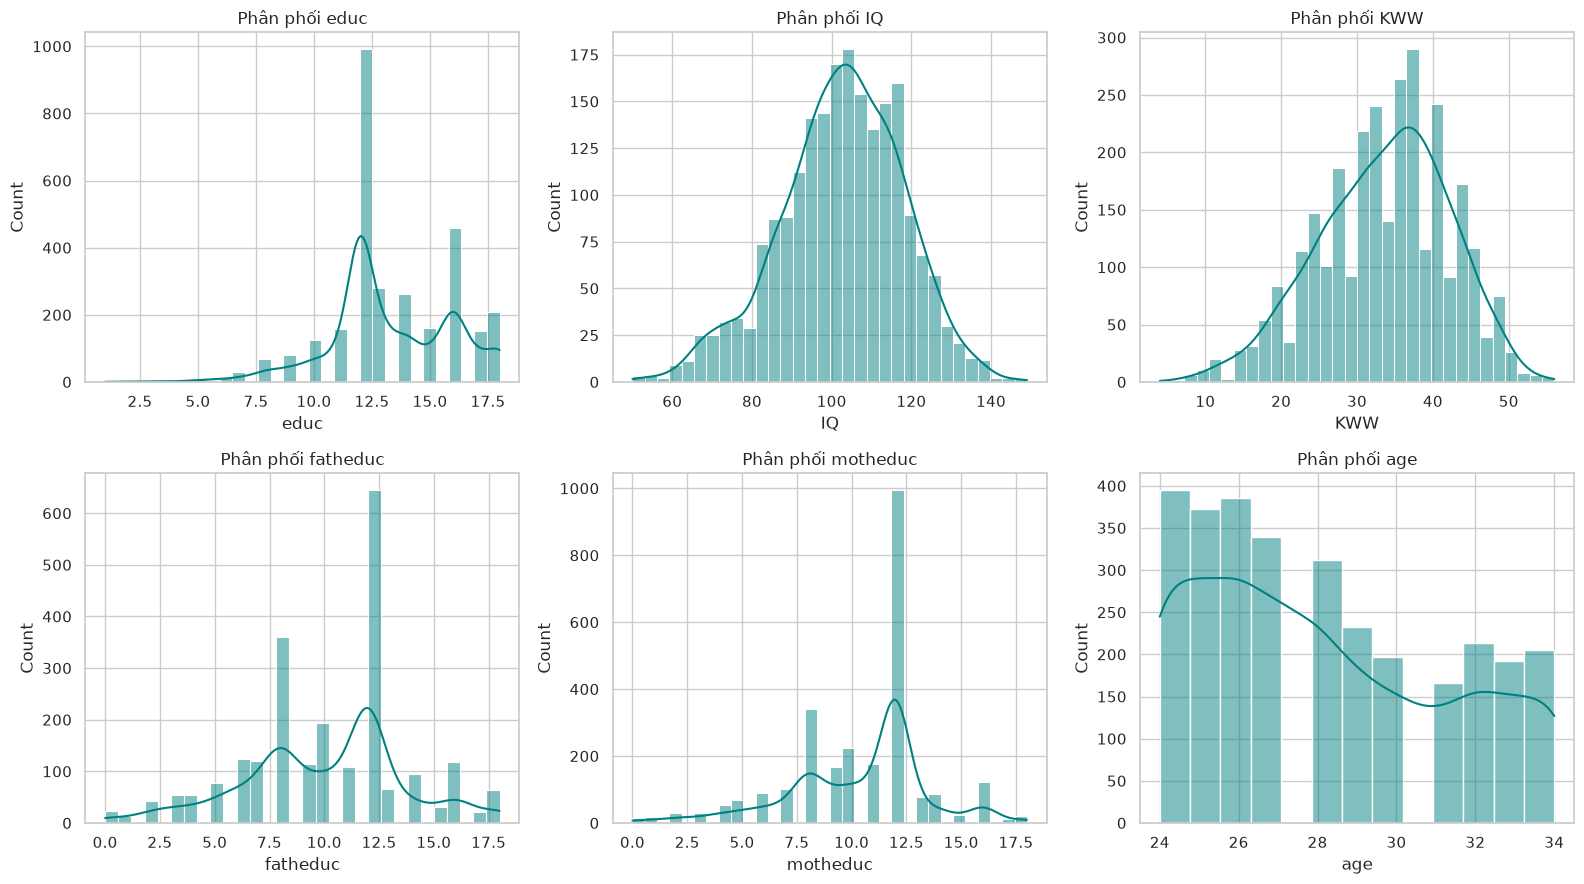

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, c in zip(axes.flat, ["educ", "IQ", "KWW", "fatheduc", "motheduc", "age"]):
    sns.histplot(df[c].dropna(), kde=True, ax=ax, color="teal")
    ax.set_title(f"Phân phối {c}")
plt.tight_layout()
plt.show()


### 2.5 Trực quan hóa: Ma trận tương quan

### 2.6 Trực quan hóa: `educ` theo nhóm (black / nearc4 / momdad14)

/tmp/ipykernel_24501/597008801.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="black", y="educ", data=df, ax=axes[0], palette="Set2")
/tmp/ipykernel_24501/597008801.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="nearc4", y="educ", data=df, ax=axes[1], palette="Set2")
/tmp/ipykernel_24501/597008801.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="momdad14", y="educ", data=df, ax=axes[2], palette="Set2")


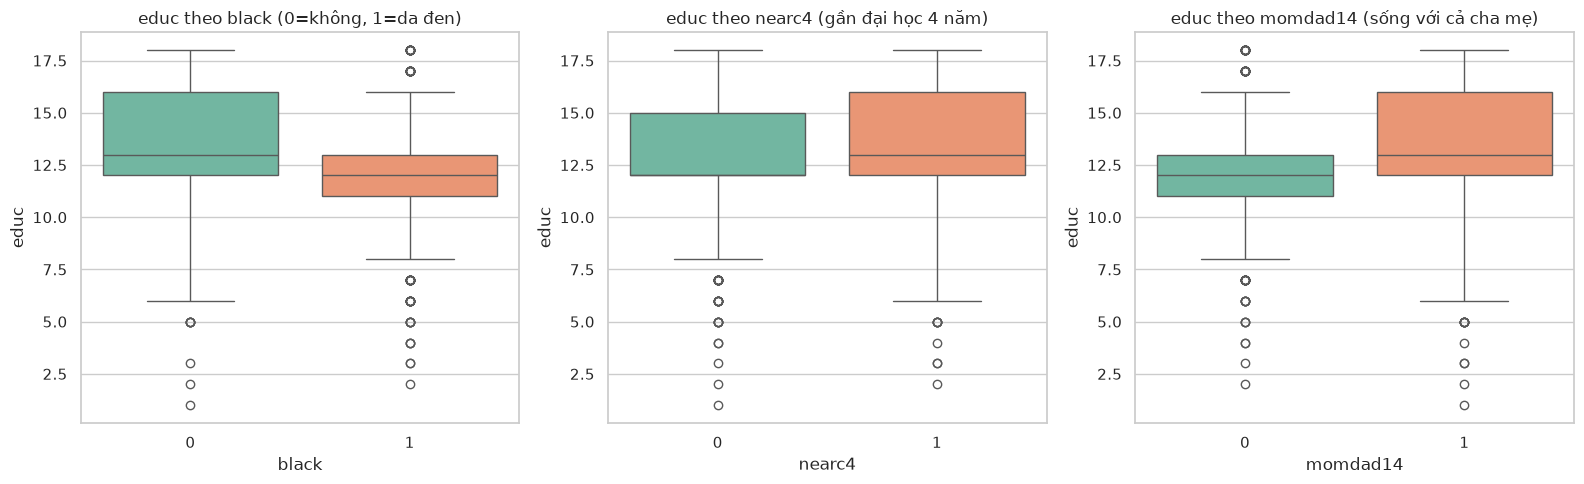

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.boxplot(x="black", y="educ", data=df, ax=axes[0], palette="Set2")
axes[0].set_title("educ theo black (0=không, 1=da đen)")

sns.boxplot(x="nearc4", y="educ", data=df, ax=axes[1], palette="Set2")
axes[1].set_title("educ theo nearc4 (gần đại học 4 năm)")

sns.boxplot(x="momdad14", y="educ", data=df, ax=axes[2], palette="Set2")
axes[2].set_title("educ theo momdad14 (sống với cả cha mẹ)")

plt.tight_layout()
plt.show()


### 2.7 Trực quan hóa: Educ trung bình theo vùng (reg661-reg669)

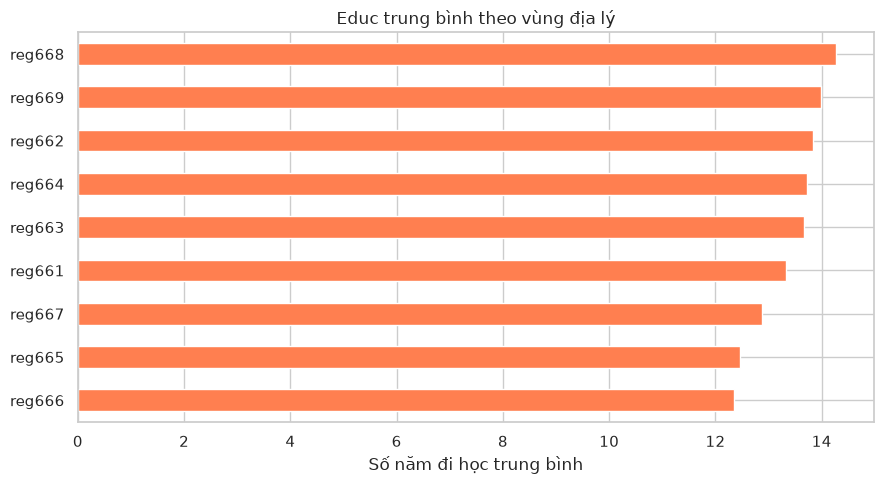

In [35]:
reg_cols = [c for c in df.columns if c.startswith("reg66")]
reg_means = {c: df.loc[df[c] == 1, "educ"].mean() for c in reg_cols}
reg_series = pd.Series(reg_means).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
reg_series.plot(kind="barh", color="coral", ax=ax)
ax.set_title("Educ trung bình theo vùng địa lý")
ax.set_xlabel("Số năm đi học trung bình")
plt.tight_layout()
plt.show()


### 2.8 Trực quan hóa: Scatter educ vs IQ / KWW / fatheduc / motheduc

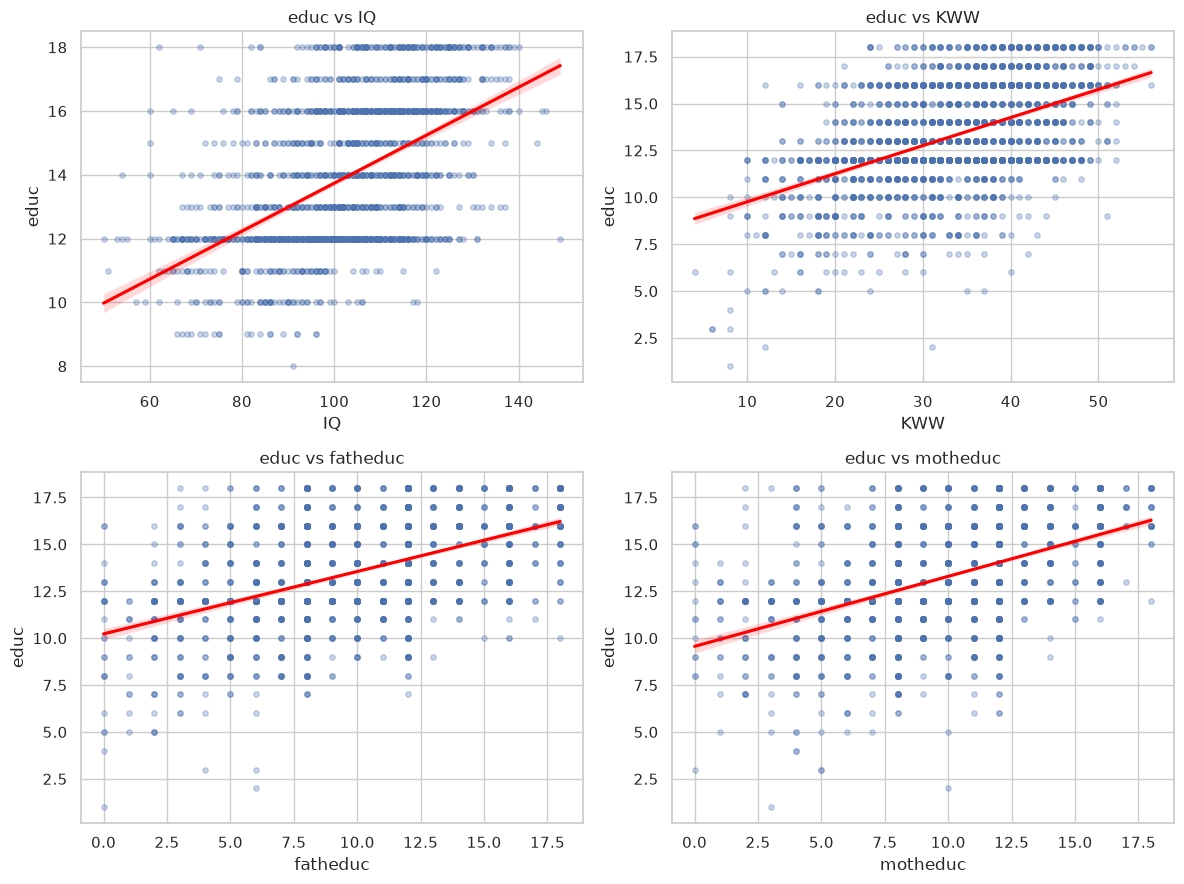

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
pairs = [("IQ", axes[0,0]), ("KWW", axes[0,1]), ("fatheduc", axes[1,0]), ("motheduc", axes[1,1])]
for var, ax in pairs:
    sns.regplot(x=var, y="educ", data=df, ax=ax, scatter_kws={"alpha":0.3, "s":15},
                line_kws={"color":"red"})
    ax.set_title(f"educ vs {var}")
plt.tight_layout()
plt.show()


### 2.9 Trực quan hóa: Outlier check (boxplot)

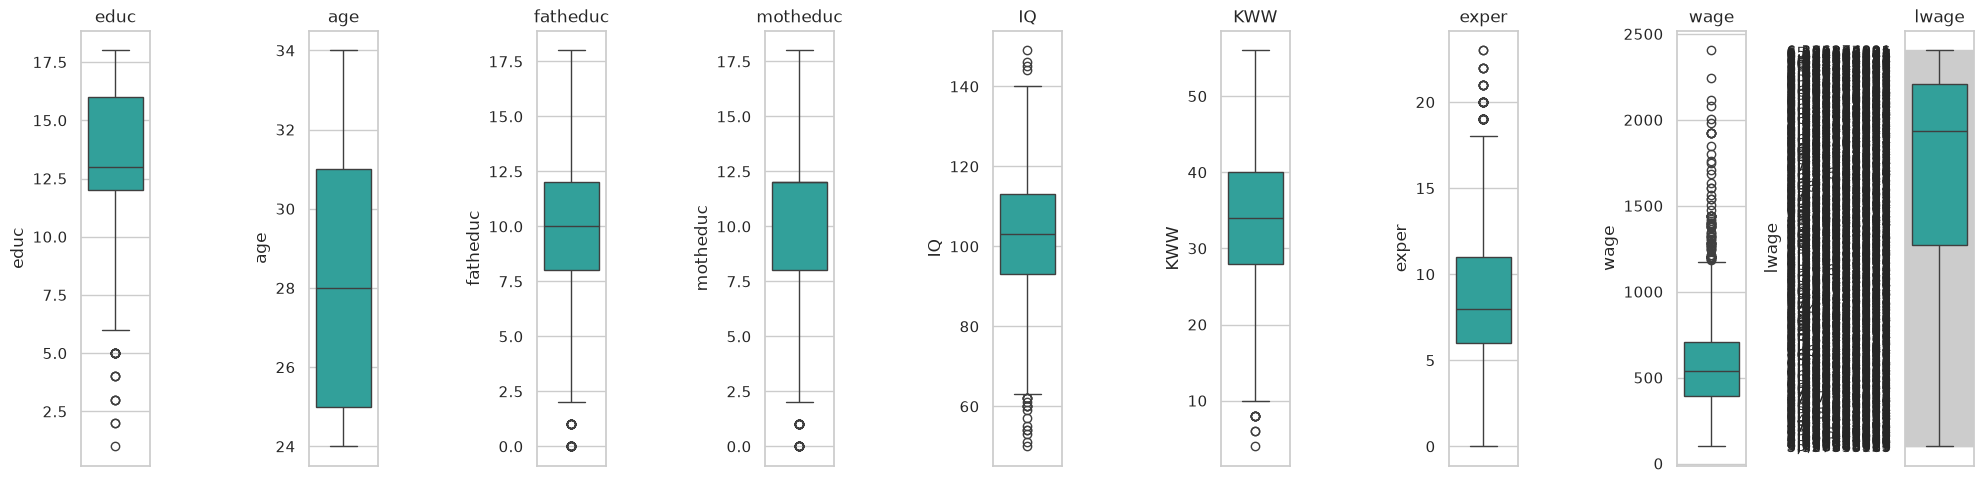

In [37]:
fig, axes = plt.subplots(1, len(num_vars), figsize=(20, 5))
for ax, c in zip(axes, num_vars):
    sns.boxplot(y=df[c], ax=ax, color="lightseagreen")
    ax.set_title(c)
plt.tight_layout()
plt.show()


### 2.10 Bảng: Educ trung bình theo cấu trúc gia đình (14 tuổi)

In [38]:
fam_vars = ["momdad14", "sinmom14", "step14", "libcrd14"]
fam_summary = pd.DataFrame({
    v: df.groupby(v)["educ"].agg(["mean", "count"]).stack()
    for v in fam_vars
})
fam_summary


momdad14     sinmom14       step14     libcrd14
0 mean     12.287066    13.375323    13.281714    11.862705
  count   634.000000  2707.000000  2893.000000   976.000000
1 mean     13.523990    12.264026    12.811966    13.947056
  count  2376.000000   303.000000   117.000000  2021.000000

## 3. Xử lý dữ liệu thiếu

Impute median cho các biến định lượng bị thiếu (`fatheduc`, `motheduc`, `IQ`, `KWW`, `libcrd14`).
Chọn median vì các biến này lệch nhẹ / có outlier, median ổn định hơn mean.

In [39]:
model_df = df.copy()
for c in ["fatheduc", "motheduc", "IQ", "KWW", "libcrd14"]:
    model_df[c] = model_df[c].fillna(model_df[c].median())

model_df[["fatheduc", "motheduc", "IQ", "KWW", "libcrd14"]].isnull().sum()


fatheduc    0
motheduc    0
IQ          0
KWW         0
libcrd14    0
dtype: int64

## 4. OLS: 3 mô hình theo nhóm biến

- **Model 1 — Gia đình:** `fatheduc, motheduc, momdad14, sinmom14, step14, libcrd14, black`
- **Model 2 — + Năng lực nhận thức:** Model 1 + `IQ, KWW`
- **Model 3 — Đầy đủ:** Model 2 + địa lý (`nearc2, nearc4, south66, smsa66, reg661-reg668`)

> Lưu ý: không dùng `exper` làm biến giải thích vì `exper = age - educ - 6` gây rò rỉ dữ liệu (data leakage) với biến mục tiêu.

In [40]:
m1_vars = ["fatheduc", "motheduc", "momdad14", "sinmom14", "step14", "libcrd14", "black"]
m2_vars = m1_vars + ["IQ", "KWW"]
m3_vars = m2_vars + ["nearc2", "nearc4", "south66", "smsa66",
                     "reg661", "reg662", "reg663", "reg664",
                     "reg665", "reg666", "reg667", "reg668"]

def fit_ols(vars_, name):
    X = sm.add_constant(model_df[vars_])
    y = model_df["educ"]
    model = sm.OLS(y, X).fit()
    print(f"===== {name} =====")
    print(f"R2 = {model.rsquared:.4f} | Adj-R2 = {model.rsquared_adj:.4f}")
    return model

ols1 = fit_ols(m1_vars, "OLS Model 1: Gia đình")
ols2 = fit_ols(m2_vars, "OLS Model 2: + Năng lực nhận thức")
ols3 = fit_ols(m3_vars, "OLS Model 3: Đầy đủ")


===== OLS Model 1: Gia đình =====
R2 = 0.2795 | Adj-R2 = 0.2778
===== OLS Model 2: + Năng lực nhận thức =====
R2 = 0.3820 | Adj-R2 = 0.3801
===== OLS Model 3: Đầy đủ =====
R2 = 0.3902 | Adj-R2 = 0.3861


In [41]:
ols3.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   educ   R-squared:                       0.390
Model:                            OLS   Adj. R-squared:                  0.386
Method:                 Least Squares   F-statistic:                     95.63
Date:                Mon, 20 Jul 2026   Prob (F-statistic):          2.11e-302
Time:                        02:38:33   Log-Likelihood:                -6490.0
No. Observations:                3010   AIC:                         1.302e+04
Df Residuals:                    2989   BIC:                         1.315e+04
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.5769      0.411      6.269      0.000       1.771       3.383
fatheduc       0.1397      0.014      9.727      0.000       0.112       0.168
motheduc       0.1275      0.016      8.187      0.000       0.097       0.158
momdad14       0.8558      0.158      5.421      0.000       0.546       1.165
sinmom14       0.1285      0.193      0.666      0.506      -0.250       0.507
step14         0.3097      0.246      1.260      0.208      -0.172       0.792
libcrd14       0.8469      0.095      8.926      0.000       0.661       1.033
black          0.4389      0.114      3.848      0.000       0.215       0.662
IQ             0.0376      0.003     11.598      0.000       0.031       0.044
KWW            0.0910      0.005     16.949      0.000       0.080       0.102
nearc2        -0.0672      0.084     -0.803      0.422      -0.232       0.097
nearc4         0.2937      0.095      3.093      0.002       0.108       0.480
south66       -0.2831      0.116     -2.441      0.015      -0.510      -0.056
smsa66        -0.1646      0.097     -1.694      0.090      -0.355       0.026
reg661        -1.1045      0.221     -4.996      0.000      -1.538      -0.671
reg662        -0.4701      0.160     -2.936      0.003      -0.784      -0.156
reg663        -0.4546      0.158     -2.882      0.004      -0.764      -0.145
reg664        -0.3614      0.205     -1.764      0.078      -0.763       0.040
reg665        -0.2173      0.085     -2.567      0.010      -0.383      -0.051
reg666        -0.1093      0.109     -1.002      0.316      -0.323       0.104
reg667         0.0435      0.102      0.426      0.670      -0.156       0.243
reg668        -0.0385      0.266     -0.145      0.885      -0.559       0.482
==============================================================================
Omnibus:                       24.360   Durbin-Watson:                   1.823
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               32.174
Skew:                          -0.111   Prob(JB):                     1.03e-07
Kurtosis:                       3.455   Cond. No.                     2.19e+17
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 7.59e-28. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

### So sánh R² giữa 3 mô hình OLS

                Model        R2    Adj_R2  N_vars
0   Model 1: Gia đình  0.279530  0.277850       7
1  Model 2: +Năng lực  0.381956  0.380102       9
2     Model 3: Đầy đủ  0.390188  0.386107      21


/tmp/ipykernel_24501/3099130937.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="R2", data=ols_compare, palette="viridis", ax=ax)


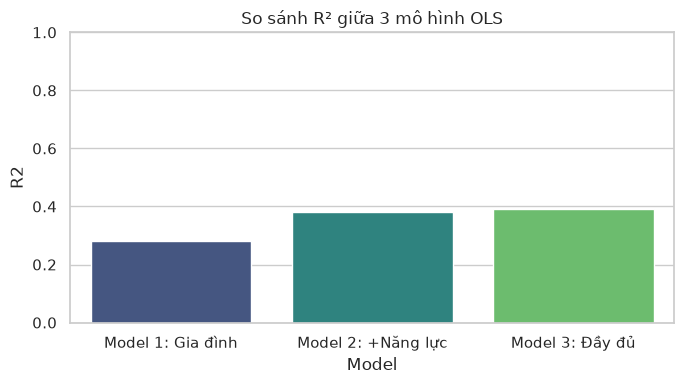

In [42]:
ols_compare = pd.DataFrame({
    "Model": ["Model 1: Gia đình", "Model 2: +Năng lực", "Model 3: Đầy đủ"],
    "R2": [ols1.rsquared, ols2.rsquared, ols3.rsquared],
    "Adj_R2": [ols1.rsquared_adj, ols2.rsquared_adj, ols3.rsquared_adj],
    "N_vars": [len(m1_vars), len(m2_vars), len(m3_vars)]
})
print(ols_compare)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x="Model", y="R2", data=ols_compare, palette="viridis", ax=ax)
ax.set_title("So sánh R² giữa 3 mô hình OLS")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


## 5. ML: Linear Regression, Ridge, Lasso, Random Forest Regressor

Sử dụng toàn bộ tập biến đầu vào (gia đình + năng lực + địa lý), chia train/test 80/20.
Các mô hình tuyến tính được chuẩn hóa (StandardScaler); Random Forest không cần chuẩn hóa.

In [43]:
feature_cols = ["IQ", "KWW", "fatheduc", "motheduc", "momdad14", "sinmom14", "step14",
                "libcrd14", "black", "nearc2", "nearc4", "south66", "smsa66",
                "reg661", "reg662", "reg663", "reg664", "reg665", "reg666", "reg667",
                "reg668", "reg669"]

X = model_df[feature_cols]
y = model_df["educ"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, random_state=42),
    "Lasso": Lasso(alpha=0.01, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42)
}


In [44]:
results = []
predictions = {}

for name, model in models.items():
    if name == "Random Forest":
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
    else:
        model.fit(X_train_s, y_train)
        pred = model.predict(X_test_s)

    predictions[name] = pred
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    results.append([name, rmse, mae, r2])

results_df = pd.DataFrame(results, columns=["Model", "RMSE", "MAE", "R2"])
results_df.round(4)


,Model,RMSE,MAE,R2
0,Linear Regression,2.0756,1.6587,0.3623
1,Ridge,2.0756,1.6587,0.3623
2,Lasso,2.0759,1.6606,0.3621
3,Random Forest,2.0132,1.6112,0.4001


### Trực quan hóa: So sánh RMSE / MAE / R² giữa các mô hình

/tmp/ipykernel_24501/2047053656.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y=metric, data=results_df, palette="mako", ax=ax)
/tmp/ipykernel_24501/2047053656.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y=metric, data=results_df, palette="mako", ax=ax)
/tmp/ipykernel_24501/2047053656.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y=metric, data=results_df, palette="mako", ax=ax)


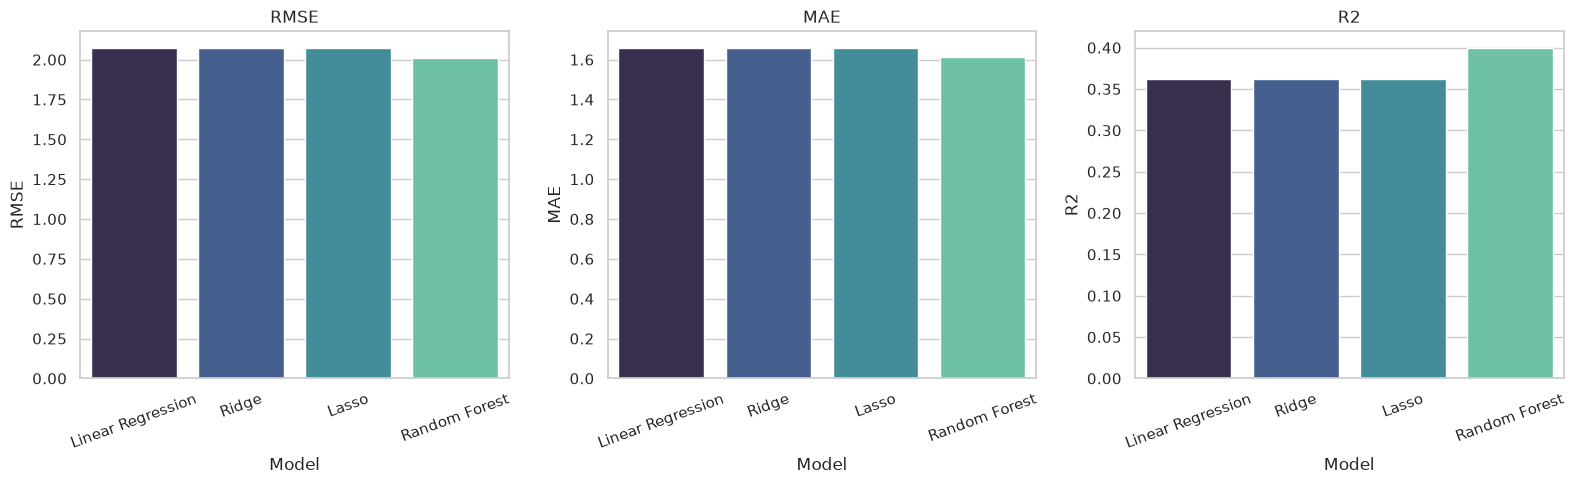

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric in zip(axes, ["RMSE", "MAE", "R2"]):
    sns.barplot(x="Model", y=metric, data=results_df, palette="mako", ax=ax)
    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


### Trực quan hóa: Predicted vs Actual (Random Forest)

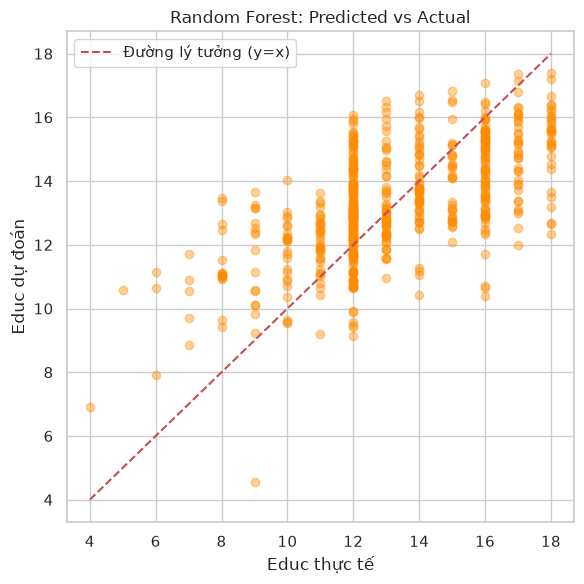

In [46]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, predictions["Random Forest"], alpha=0.4, color="darkorange")
lims = [y_test.min(), y_test.max()]
ax.plot(lims, lims, "r--", label="Đường lý tưởng (y=x)")
ax.set_xlabel("Educ thực tế")
ax.set_ylabel("Educ dự đoán")
ax.set_title("Random Forest: Predicted vs Actual")
ax.legend()
plt.tight_layout()
plt.show()


## 6. So sánh bằng Cross-Validation (5-fold)

In [47]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
X_scaled_full = scaler.fit_transform(X)

cv_records = []
for name, model in models.items():
    if name == "Random Forest":
        scores = cross_val_score(model, X, y, cv=kf, scoring="r2")
    else:
        scores = cross_val_score(model, X_scaled_full, y, cv=kf, scoring="r2")
    for fold_i, s in enumerate(scores, 1):
        cv_records.append([name, fold_i, s])

cv_df = pd.DataFrame(cv_records, columns=["Model", "Fold", "R2"])
cv_summary = cv_df.groupby("Model")["R2"].agg(["mean", "std"]).round(4)
cv_summary


,mean,std
Model,,
Lasso,0.3810,0.0127
Linear Regression,0.3803,0.0124
Random Forest,0.4283,0.0192
Ridge,0.3803,0.0124


/tmp/ipykernel_24501/606396511.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Model", y="R2", data=cv_df, palette="crest", ax=ax)


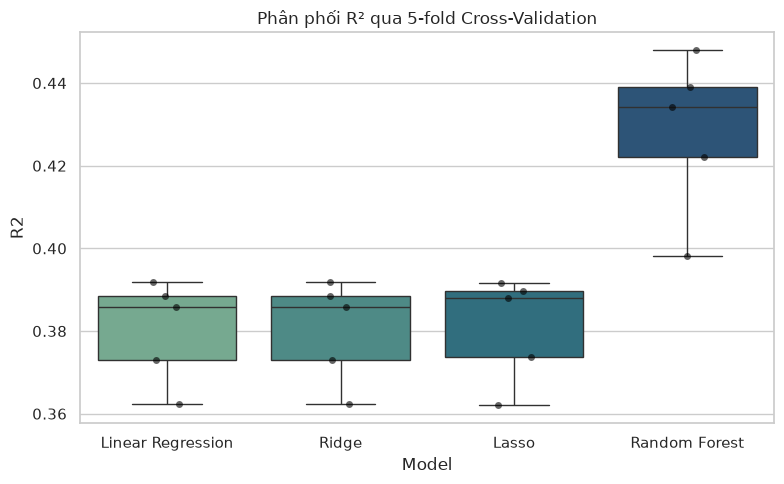

In [48]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x="Model", y="R2", data=cv_df, palette="crest", ax=ax)
sns.stripplot(x="Model", y="R2", data=cv_df, color="black", alpha=0.6, ax=ax)
ax.set_title("Phân phối R² qua 5-fold Cross-Validation")
plt.tight_layout()
plt.show()


## 7. Feature Importance

/tmp/ipykernel_24501/3099056412.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf_importance.values, y=rf_importance.index, palette="rocket", ax=ax)


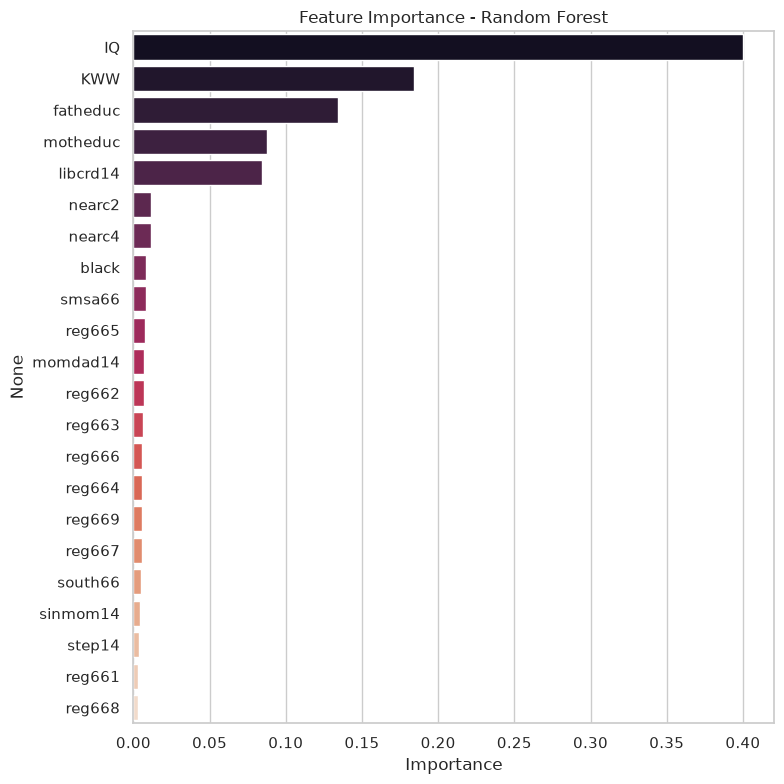

IQ          0.400377
KWW         0.183960
fatheduc    0.134554
motheduc    0.087820
libcrd14    0.084594
nearc2      0.011440
nearc4      0.011357
black       0.008500
smsa66      0.007952
reg665      0.007633
momdad14    0.007218
reg662      0.007130
reg663      0.005978
reg666      0.005774
reg664      0.005712
reg669      0.005474
reg667      0.005308
south66     0.004814
sinmom14    0.004536
step14      0.003712
reg661      0.003119
reg668      0.003039
dtype: float64

In [49]:
rf_model = models["Random Forest"]
rf_importance = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
sns.barplot(x=rf_importance.values, y=rf_importance.index, palette="rocket", ax=ax)
ax.set_title("Feature Importance - Random Forest")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

rf_importance


### So sánh hệ số chuẩn hóa (Linear/Ridge/Lasso) với Feature Importance (RF)

In [50]:
coef_df = pd.DataFrame({
    "Linear": models["Linear Regression"].coef_,
    "Ridge": models["Ridge"].coef_,
    "Lasso": models["Lasso"].coef_,
    "RF_importance": rf_model.feature_importances_
}, index=feature_cols)

coef_df.sort_values("RF_importance", ascending=False)


,Linear,Ridge,Lasso,RF_importance
IQ,0.491955,0.491815,0.482941,0.400377
KWW,0.782807,0.782428,0.768981,0.183960
fatheduc,0.449508,0.449423,0.442716,0.134554
motheduc,0.379019,0.378941,0.371774,0.087820
libcrd14,0.408190,0.408099,0.398896,0.084594
nearc2,-0.075762,-0.075692,-0.063469,0.011440
nearc4,0.137307,0.137251,0.117203,0.011357
black,0.193117,0.192724,0.164113,0.008500
smsa66,-0.039618,-0.039494,-0.021600,0.007952
reg665,-0.056078,-0.056061,-0.036681,0.007633


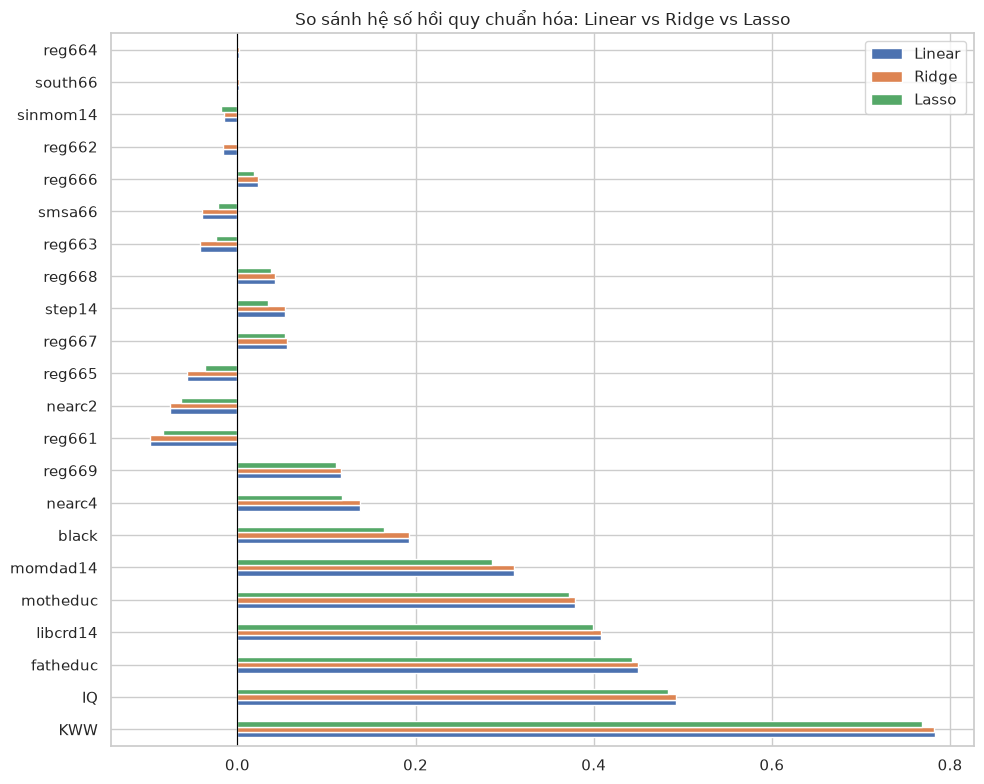

In [51]:
fig, ax = plt.subplots(figsize=(10, 8))
coef_df[["Linear", "Ridge", "Lasso"]].sort_values("Linear", key=abs, ascending=False).plot(
    kind="barh", ax=ax
)
ax.set_title("So sánh hệ số hồi quy chuẩn hóa: Linear vs Ridge vs Lasso")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()


## 8. Tổng kết

- **OLS:** Thêm nhóm biến năng lực nhận thức (`IQ`, `KWW`) giúp R² tăng mạnh nhất (Model 1 → Model 2); thêm biến địa lý cải thiện ít hơn (Model 2 → Model 3).
- **ML:** Random Forest cho RMSE/MAE thấp nhất và R² cao nhất trên tập test, cũng như khi so sánh Cross-Validation — cho thấy có quan hệ phi tuyến giữa các biến đầu vào và `educ`.
- **Feature Importance:** `IQ`, `KWW`, `fatheduc`, `motheduc`, `libcrd14` là các yếu tố quan trọng nhất, khớp với hệ số hồi quy tuyến tính (Linear/Ridge/Lasso) và tương quan đã thấy ở phần EDA.
- **Hạn chế:** R² tổng thể (~0.36–0.40) cho thấy còn nhiều yếu tố khác chưa được đo lường (động lực học tập, chất lượng trường học, biến động kinh tế địa phương...) ảnh hưởng đến số năm đi học.
